Nama : Bondan Banuaji

NIM : 231351030

Prodi : Informatika Pagi B

# 1. Membangun Model Decision Tree

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

In [142]:
df = pd.read_csv('heart.csv')

In [143]:
df.head()

,Age,Cholesterol Level,Blood Pressure,Smoking,Physical Activity,BMI,Heart Disease Risk
0,55,High,High,Yes,Low,Overweight,High
1,43,Normal,Normal,No,Moderate,Normal,Low
2,60,High,High,Yes,Low,Obese,High
3,35,Normal,Low,No,High,Normal,Low
4,50,High,High,No,Low,Overweight,Medium


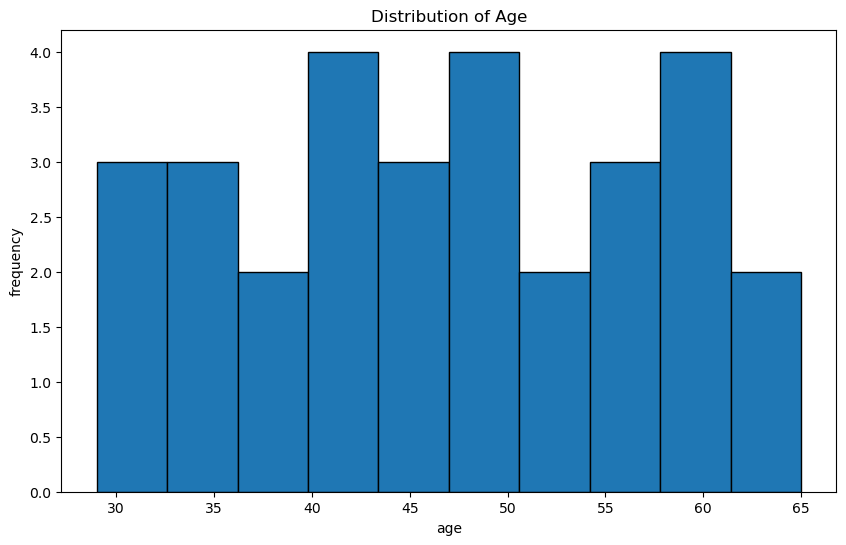

In [144]:
# 1. Histogram of Age
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=10, edgecolor='black')
plt.title("Distribution of Age")
plt.xlabel("age")
plt.ylabel("frequency")
plt.show()

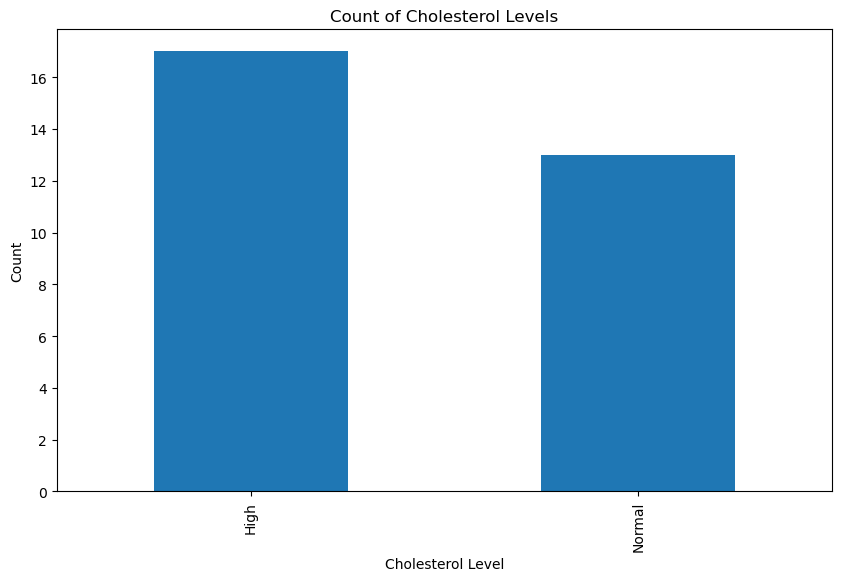

In [145]:
#2. Bar plot of cholestrol level counts
plt.figure(figsize=(10, 6))
df['Cholesterol Level'].value_counts().plot(kind='bar') 
plt.title("Count of Cholesterol Levels")
plt.xlabel("Cholesterol Level")
plt.ylabel("Count")
plt.show()

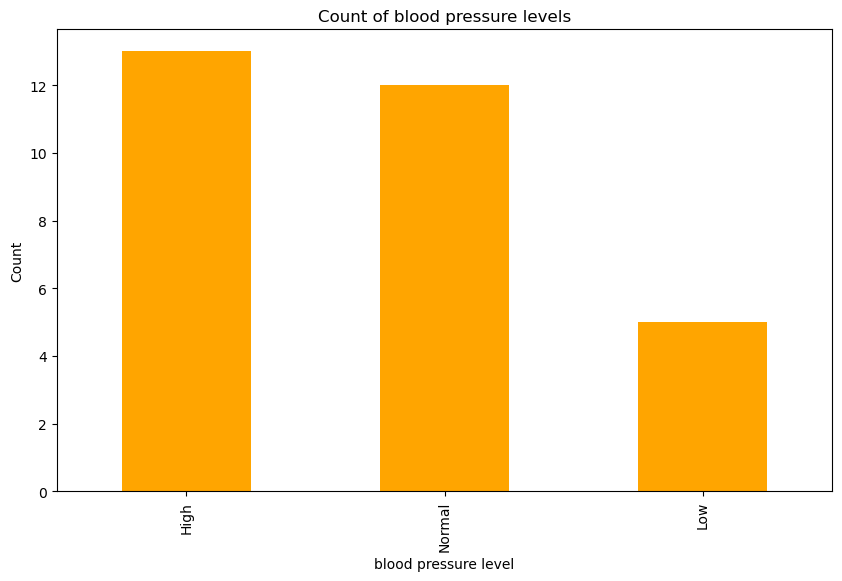

In [146]:
#3. Bar plot of blood pressure counts
plt.figure(figsize=(10, 6))
df['Blood Pressure'].value_counts().plot(kind='bar', color='orange')
plt.title("Count of blood pressure levels")
plt.xlabel("blood pressure level")
plt.ylabel("Count")
plt.show()

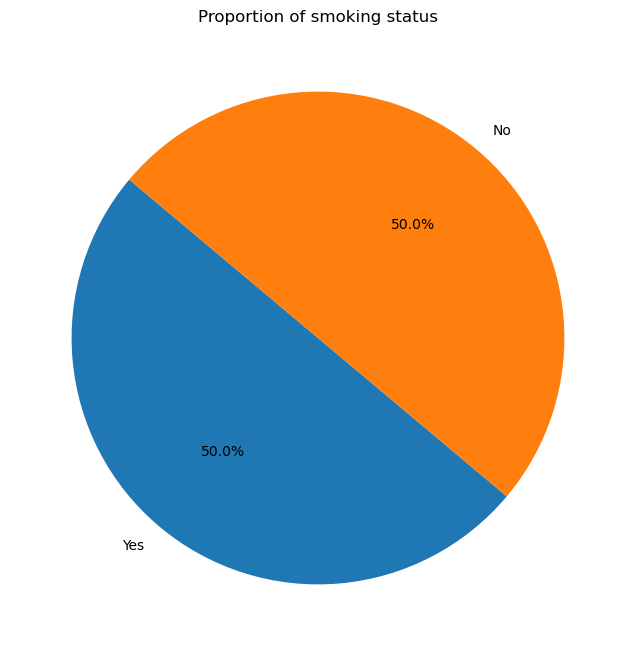

In [147]:
# 4. Pie chart of smoking status
plt.figure(figsize=(8, 8))
df['Smoking'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title("Proportion of smoking status")
plt.ylabel("")
plt.show()

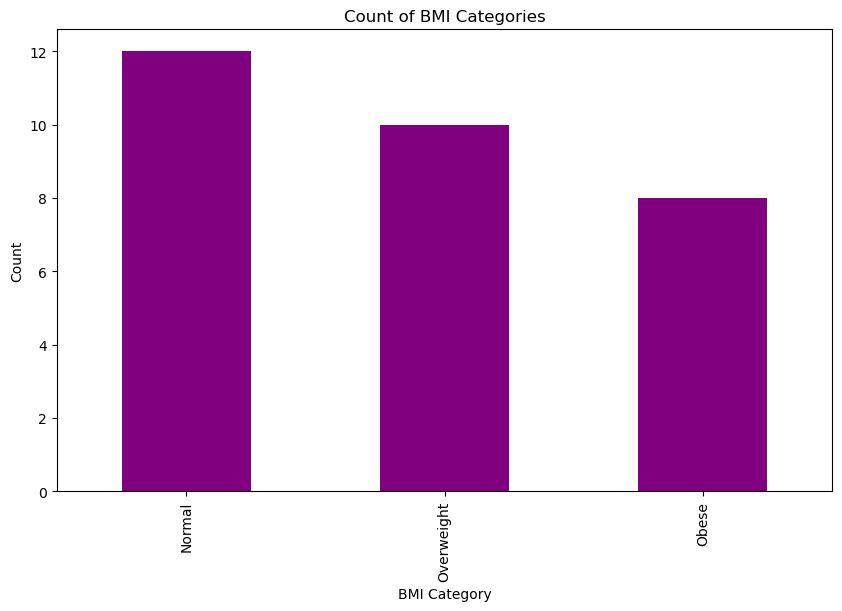

In [148]:
# 5. Count plot of BMI categories
plt.figure(figsize=(10, 6))
df['BMI'].value_counts().plot(kind='bar', color='purple')
plt.title("Count of BMI Categories")
plt.xlabel("BMI Category")
plt.ylabel("Count")
plt.show()

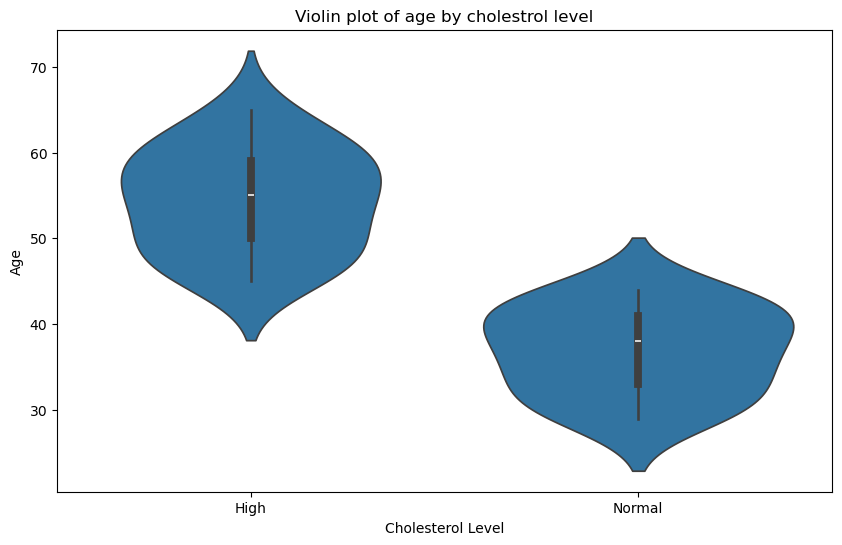

In [149]:
# 6. Violin plot of age by cholestrol level
plt.figure(figsize=(10, 6))
sns.violinplot(x='Cholesterol Level', y='Age', data=df)
plt.title("Violin plot of age by cholestrol level")
plt.xlabel("Cholesterol Level")
plt.ylabel("Age")
plt.show()

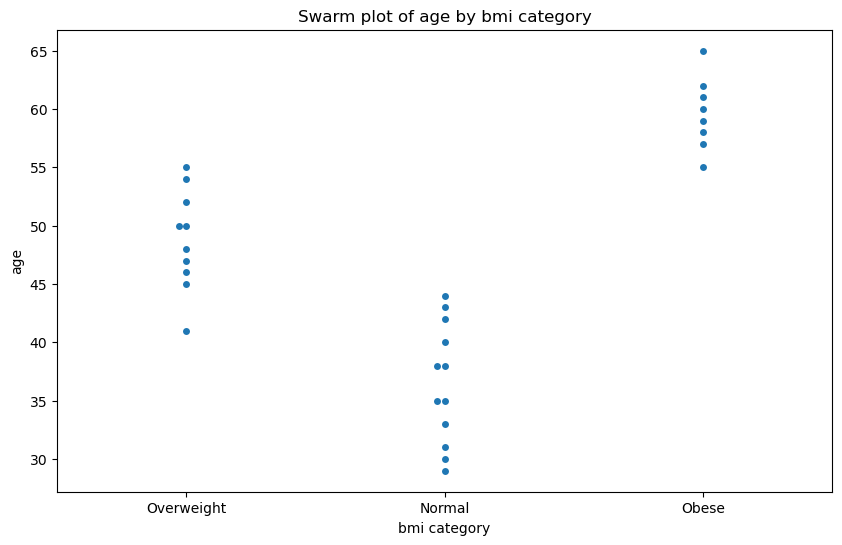

In [150]:
# 7. Swarm plot of age by BMI category
plt.figure(figsize=(10, 6))
sns.swarmplot(x='BMI', y='Age', data=df)
plt.title("Swarm plot of age by bmi category")
plt.xlabel("bmi category")
plt.ylabel("age")
plt.show()

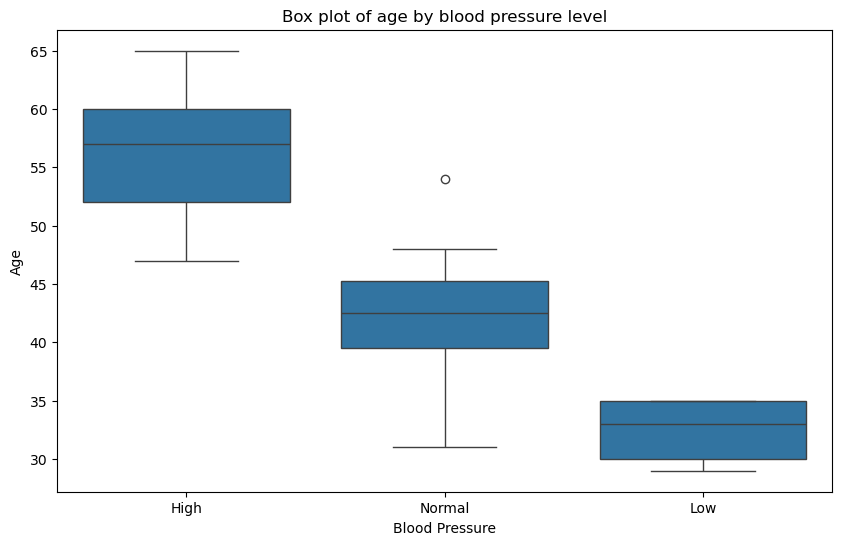

In [151]:
# 8. Box plot of age by blood pressure
plt.figure(figsize=(10, 6))
sns.boxplot(x='Blood Pressure', y='Age', data=df)
plt.title("Box plot of age by blood pressure level")
plt.xlabel("Blood Pressure")
plt.ylabel("Age")
plt.show()

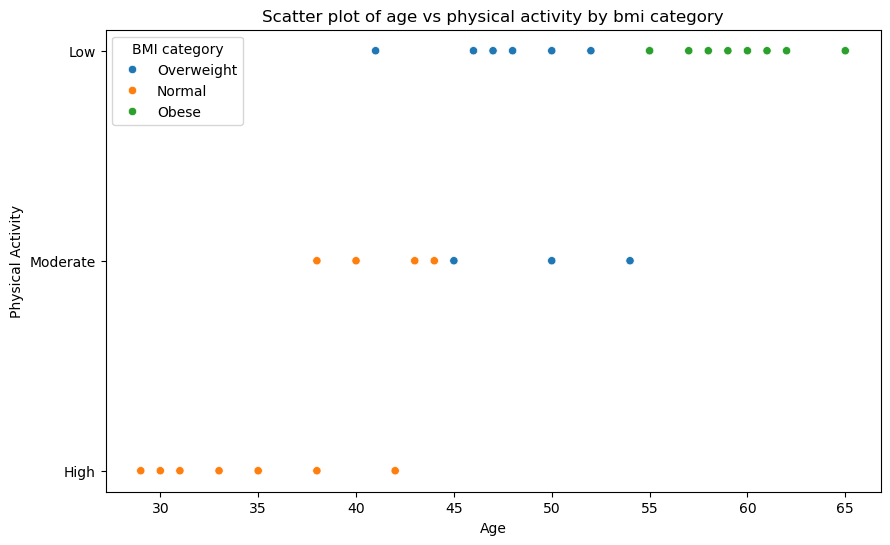

In [152]:
# 9. Scatter plot of age vs physical activity with bmi category as Hue
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Physical Activity', hue='BMI')
plt.title("Scatter plot of age vs physical activity by bmi category")
plt.xlabel("Age")
plt.ylabel("Physical Activity")
plt.legend(title="BMI category")
plt.show()

In [153]:
def categorize_age(age):
    if age < 35:
        return "Young"
    elif age < 55:
        return "Middle-aged"
    else:
        return "Senior"

In [154]:
df['Age'] = df['Age'].apply(categorize_age)
df.head()

,Age,Cholesterol Level,Blood Pressure,Smoking,Physical Activity,BMI,Heart Disease Risk
0,Senior,High,High,Yes,Low,Overweight,High
1,Middle-aged,Normal,Normal,No,Moderate,Normal,Low
2,Senior,High,High,Yes,Low,Obese,High
3,Middle-aged,Normal,Low,No,High,Normal,Low
4,Middle-aged,High,High,No,Low,Overweight,Medium


In [155]:
label_encoders = {}
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

In [156]:
df.head()

,Age,Cholesterol Level,Blood Pressure,Smoking,Physical Activity,BMI,Heart Disease Risk
0,1,0,0,1,1,2,0
1,0,1,2,0,2,0,1
2,1,0,0,1,1,1,0
3,0,1,1,0,0,0,1
4,0,0,0,0,1,2,2


In [157]:
x = df.drop('Heart Disease Risk', axis=1)
y = df['Heart Disease Risk']

In [158]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [159]:
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [160]:
y_pred = model.predict(X_test)

# 2. Simulasi Algoritma Decision Tree

In [161]:
# Simulate new input data
new_data = pd.DataFrame({
    'Age': [label_encoders['Age'].transform(['Middle-aged'])[0]],
    'Cholesterol Level': [label_encoders['Cholesterol Level'].transform(['High'])[0]], 
    'Blood Pressure': [label_encoders['Blood Pressure'].transform(['High'])[0]],
    'Smoking': [label_encoders['Smoking'].transform(['Yes'])[0]],
    'Physical Activity': [label_encoders['Physical Activity'].transform(['Low'])[0]], 
    'BMI': [label_encoders['BMI'].transform(['Overweight'])[0]], 
})

In [162]:
new_prediction = model.predict(new_data)

In [163]:
new_prediction_decoded = label_encoders['Heart Disease Risk'].inverse_transform(new_prediction)

In [164]:
new_prediction_decoded

array(['High'], dtype=object)

# 3. Evaluasi Algoritma Decision tree

In [165]:
# Calculate accuracy and confusion matrix
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

In [166]:
accuracy, conf_matrix

(1.0,
 array([[3, 0, 0],
        [0, 5, 0],
        [0, 0, 1]]))

# 4. Plot Hasil Decision Tree

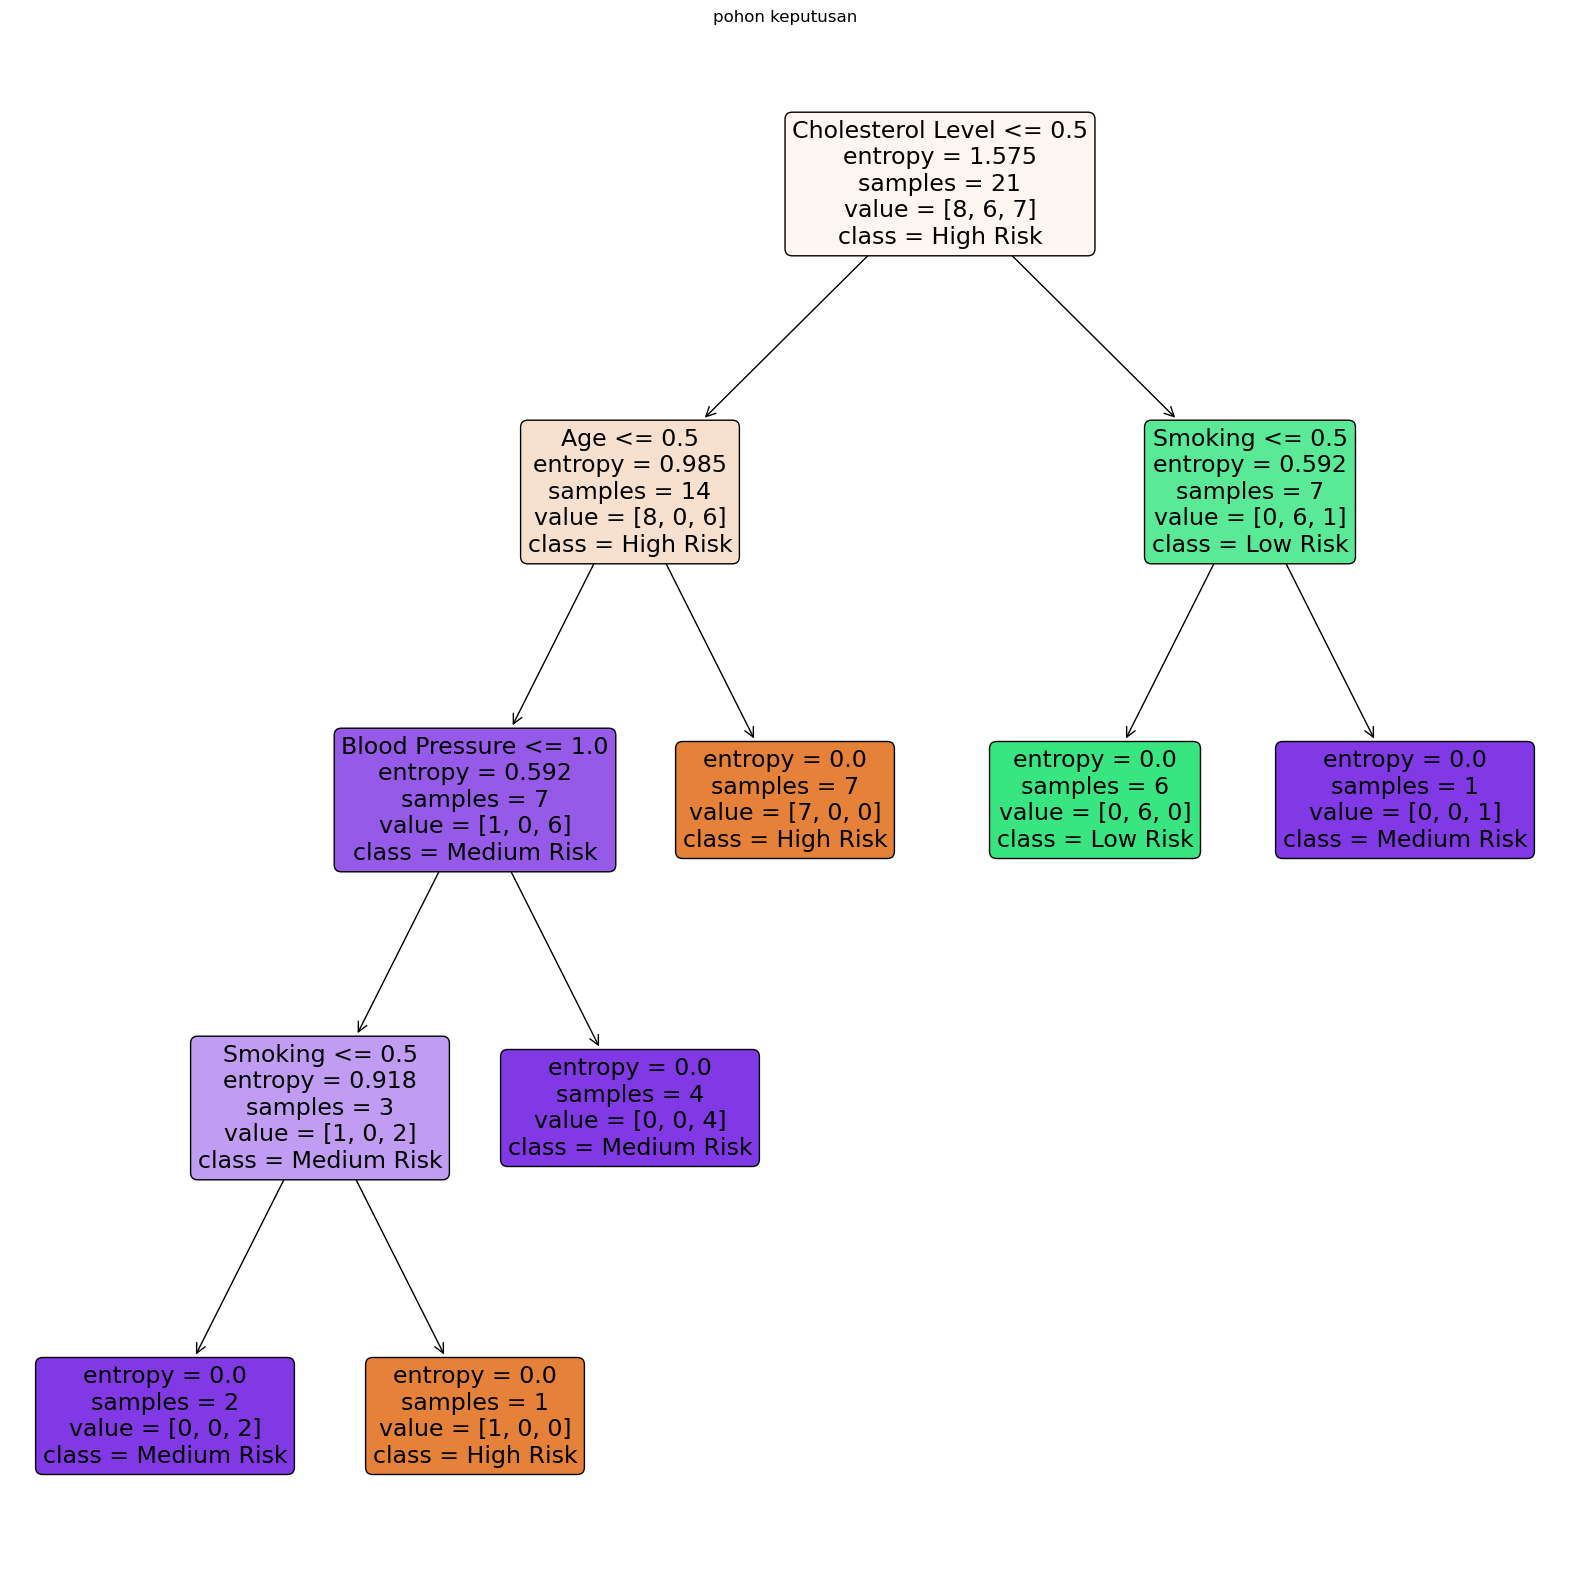

In [167]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 20))
plot_tree(model, feature_names=['Age',
                                'Cholesterol Level',
                                'Blood Pressure',
                                'Smoking',
                                'Physical Activity',
                                'BMI'], class_names=['High Risk',
                                                     'Low Risk',
                                                     'Medium Risk'
], filled=True, rounded=True)
plt.title("pohon keputusan")
plt.show()

In [168]:
# Save the trained C4.5 decision tree model
import pickle

# Save the model to a pickle file
with open('C45_pinjam_mod.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model C4.5 berhasil disimpan sebagai C45_pinjam_mod.pkl")

Model C4.5 berhasil disimpan sebagai C45_pinjam_mod.pkl
